In [28]:
import subprocess
import sys

print("Python:", sys.executable)
subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "requests"])

Python: /Library/Developer/CommandLineTools/usr/bin/python3
Defaulting to user installation because normal site-packages is not writeable


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


0

In [29]:
%pip install numpy pandas scikit-learn matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [30]:
import random 
import requests 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt


import torch 
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


dataset '

In [32]:
urls = {
    "train": "https://huggingface.co/datasets/AutonLab/Timeseries-PILE/resolve/main/classification/UCR/ECG5000/ECG5000_TRAIN.ts?download=true",
    "test": "https://huggingface.co/datasets/AutonLab/Timeseries-PILE/resolve/main/classification/UCR/ECG5000/ECG5000_TEST.ts?download=true",
}


In [33]:
def load_ecg5000_ts(urls):
    rows = []
    for split, url in urls.items():
        response = requests.get(url, timeout=30)
        response.raise_for_status()

        for line in response.text.splitlines():
            line = line.strip()
            if not line or line.startswith("#") or line.startswith("@"):
                continue

            values, label = line.rsplit(":", 1)
            rows.append([float(label), *map(float, values.split(","))])

    return pd.DataFrame(rows)


df = load_ecg5000_ts(urls)

labels = df.iloc[:, 0].values
signals = df.iloc[:, 1:].values.astype(np.float32)

print("Signals shape:", signals.shape)
print("Labels shape:", labels.shape)

Signals shape: (5000, 140)
Labels shape: (5000,)


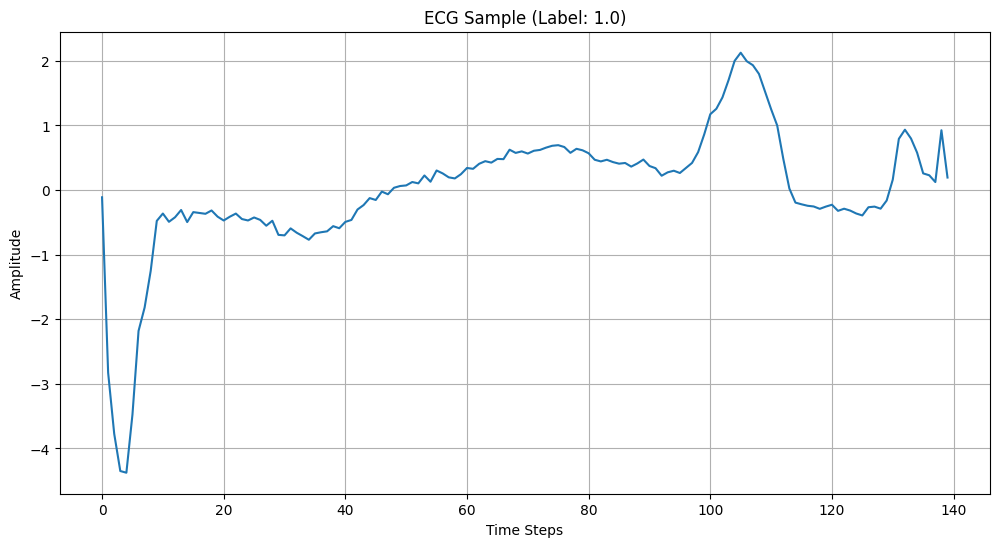

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(signals[0])
plt.title(f"ECG Sample (Label: {labels[0]})")
plt.xlabel("Time Steps")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

In [35]:
scaler=StandardScaler()
signals_scaled=scaler.fit_transform(signals)
print("Scaled signals shape:", signals_scaled.shape)

Scaled signals shape: (5000, 140)


In [36]:
def make_prediction_dataset(signals, window_size=20):
    X,y=[],[]
    
    for signal in signals:
        for i in range(len(signal)-window_size):
            X.append(signal[i:i+window_size])
            y.append(signal[i+window_size])
            
    X=np.array(X,dtype=np.float32)
    y=np.array(y,dtype=np.float32)
    
    X=X[..., np.newaxis]  # Add channel dimension for LSTM
    y=y[..., np.newaxis]  # Add channel dimension for LSTM
    
    
    return X, y

X,y = make_prediction_dataset(signals_scaled, window_size=20)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (600000, 20, 1)
y shape: (600000, 1)


In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = np.asarray(X_train, dtype=np.float32)
X_test = np.asarray(X_test, dtype=np.float32)
y_train = np.asarray(y_train, dtype=np.float32)
y_test = np.asarray(y_test, dtype=np.float32)

class ECGPredictionDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        target = torch.tensor(self.y[idx], dtype=torch.float32).reshape(1)
        return x, target


train_ds = ECGPredictionDataset(X_train, y_train)
test_ds = ECGPredictionDataset(X_test, y_test)

In [38]:
class EEG_LSTM(nn.Module):
    def __init__(self,input_size=1,hidden_size=64,num_layers=1,dropout=0.0):
        super().__init__()
        real_dropout=dropout if num_layers>1 else 0.0
        self.lstm=nn.LSTM(input_size,hidden_size,num_layers,batch_first=True,dropout=real_dropout)
        self.fc=nn.Linear(hidden_size,1)
        
    def forward(self,x):
        lstm_out,_=self.lstm(x)
        last_output=lstm_out[:,-1,:]
        out=self.fc(last_output)
        return out

MDP space and Actions 


In [39]:
hidden_space=[32,64,128]

layer_size= [1,2]
dropout_rates=[0.0,0.2,0.4]

actions=[
    "increase_hidden",
    "decrease_hidden",
    "increase_layers",
    "decrease_layers",
    "increase_dropout",
    "decrease_dropout",
    "keep"
]
states = [
    (h,l,d)
    for h in hidden_space
    for l in layer_size
    for d in dropout_rates
]

state transition function 

In [40]:
def next_state(state,action):
    h,l,d=state
    
    hi=hidden_space.index(h)
    li=layer_size.index(l)
    di=dropout_rates.index(d)
    
    
    if action == "increase_hidden":
        hi=min(hi+1,len(hidden_space)-1)
    elif action == "decrease_hidden":
        hi=max(hi-1,0)
    elif action == "increase_layers":
        li=min(li+1,len(layer_size)-1)
    elif action == "decrease_layers":
        li=max(li-1,0)
    elif action == "increase_dropout":
        di=min(di+1,len(dropout_rates)-1)
    elif action == "decrease_dropout":
        di=max(di-1,0)
        
    return (hidden_space[hi],layer_size[li],dropout_rates[di])
        

Q learning agent 

In [41]:
class QLearningOptimizer:
    def __init__(self,alpha=0.4,gamma=0.8,epislon=0.5):
        self.alpha=alpha
        self.gamma=gamma
        self.epsilon=epislon
        self.q_table={state:{action:0.0 for action in actions} for state in states}
    def choose_action(self,state):
        if random.random() < self.epsilon:
            return random.choice(actions)
        return max(self.q_table[state], key=self.q_table[state].get)
    def update(self,state,action,reward,new_state):
        curernt_q=self.q_table[state][action]
        max_future_q=max(self.q_table[new_state].values())
        td_error=reward + self.gamma*max_future_q - curernt_q
        self.q_table[state][action] += self.alpha*td_error
        return td_error
    
    def best_state(self):
        best_s=None 
        best_q=-np.inf
        for s in states:
            max_q=max(self.q_table[s].values())
            if max_q > best_q:
                best_q=max_q
                best_s=s
        return best_s
    
    

train one lstm config 

In [42]:
def train_one_config(state,train_loader,val_loader,epochs=3,batch_size=32):
    hidden_size,num_layers,dropout=state 
    if isinstance(train_loader, Dataset):
        train_loader=DataLoader(train_loader,batch_size=batch_size,shuffle=True)
    if isinstance(val_loader, Dataset):
        val_loader=DataLoader(val_loader,batch_size=batch_size,shuffle=False)
    
    model=EEG_LSTM(input_size=1,hidden_size=hidden_size,num_layers=num_layers,dropout=dropout).to(device)
    optimizer=torch.optim.Adam(model.parameters(),lr=0.001)
    criterion=nn.MSELoss()
    
    for epoch in range(epochs):
        model.train()
        
        for xb,yb in train_loader:
            xb,yb=xb.to(device),yb.to(device)
            if xb.dim() == 2:
                xb=xb.unsqueeze(-1)
            elif xb.dim() == 4 and xb.shape[-1] == 1:
                xb=xb.squeeze(-1)
            if yb.dim() == 1:
                yb=yb.unsqueeze(-1)
            pred=model(xb)
            loss=criterion(pred,yb)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
    model.eval()
    val_losses=[]
    with torch.no_grad():
        for xb,yb in val_loader:
            xb,yb=xb.to(device),yb.to(device)
            if xb.dim() == 2:
                xb=xb.unsqueeze(-1)
            elif xb.dim() == 4 and xb.shape[-1] == 1:
                xb=xb.squeeze(-1)
            if yb.dim() == 1:
                yb=yb.unsqueeze(-1)
            pred=model(xb)
            loss=criterion(pred,yb)
            val_losses.append(loss.item())
            
    val_loss=float(np.mean(val_losses))
    reward=-val_loss
    return reward,val_loss

In [ ]:
agent=QLearningOptimizer(alpha=0.4,gamma=0.8,epislon=0.5)
current_state=(64,1,0.0)

logs=[]
EPISODES=12     
for episode in range(EPISODES):
    action=agent.choose_action(current_state)
    next_s=next_state(current_state,action)
    
    reward,val_loss=train_one_config(next_s,train_ds,test_ds,epochs=3)
    td_error=agent.update(current_state,action,reward,next_s)
    logs.append({
        "episode":episode,
        "state":current_state,
        "action":action,
        "reward":reward,
        "val_loss":val_loss,
        "td_error":td_error
    })
    print(f"Episode {episode}: State={current_state}, Action={action}, Reward={reward:.4f}, Val Loss={val_loss:.4f}, TD Error={td_error:.4f}")
    current_state=next_s

Episode 0: State=(64, 1, 0.0), Action=increase_hidden, Reward=-0.0635, Val Loss=0.0635, TD Error=-0.0635
